In [2]:
!pip install -q --upgrade evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [3]:
!pip install -q --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 76.2 MB/s eta 0:00:00


In [4]:
from peft import LoraConfig, get_peft_model, TaskType
import torch
from sklearn.preprocessing import LabelEncoder
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import json
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

In [7]:
MODEL = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
MAX_LEN = 256
dataset = load_dataset("Roblox/RobloxGuard-Eval")
dataset = dataset.map(lambda x: {"category": "No violation" if x["category"] == "None" else x["category"]})
split = dataset["test"].train_test_split(test_size=0.2, seed=42)
train, test = split["train"], split["test"]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
label_encoder = LabelEncoder()
label_encoder.fit(list(train["category"]) + list(test["category"]))
num_labels = len(label_encoder.classes_)
print(f"Labels ({num_labels}): {label_encoder.classes_}")

Labels (24): ['' 'Cheating and Scams' 'Child Exploitation'
 'Directing Users Off Platform' 'Discrimination, Slurs, and Hate Speech'
 'Expanded Policies for Suitability'
 'Illegal and Regulated Goods and Activities'
 'Independent Advertisement Publishing' 'Intellectual Property Violations'
 'Misusing Roblox Systems' 'No violation' 'Paid Random Items'
 'Political Figures and Entities' 'Profanity'
 'Prohibited Advertising Practices and Content'
 'Real-World Sensitive Events' 'Romantic and Sexual Content'
 'Sharing Personal Information' 'Soliciting Donations' 'Spam'
 'Suicide, Self Injury, and Harmful Behavior'
 'Terrorism and Violent Extremism' 'Threats, Bullying, and Harassment'
 'Violent Content and Gore']


In [9]:
def preprocess(example):
    full_text = f"prompt: {example['prompt']} \n response: {example['response']}"
    model_input = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LEN,
    )
    model_input["labels"] = int(label_encoder.transform([example["category"]])[0])
    return model_input

In [10]:
tokenized_train = train.map(preprocess, remove_columns=train.column_names, num_proc=4, batched=False)
tokenized_val = test.map(preprocess, remove_columns=test.column_names, num_proc=4, batched=False)

Map (num_proc=4):   0%|          | 0/2298 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/575 [00:00<?, ? examples/s]

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=num_labels)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_CLS,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 903,960 || all params: 67,875,888 || trainable%: 1.3318


In [12]:
training_args = TrainingArguments(
    output_dir="lora-classification",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=1,
    learning_rate=2e-4,
    num_train_epochs=50,
    fp16=torch.cuda.is_available(),
    bf16=False,
    logging_steps=50,
    save_steps=200,
    save_total_limit=1,
    save_strategy="epoch",
    eval_strategy="epoch",
    report_to="none",
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    group_by_length=True,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [13]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

accuracy_metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,2.934789,1.830282,0.714783
2,1.978223,1.248984,0.714783
3,1.250473,0.948091,0.751304
4,0.963660,0.777386,0.784348
5,0.736301,0.682816,0.801739
6,0.638416,0.670644,0.803478
7,0.536356,0.766726,0.766957
8,0.476545,0.661081,0.824348
9,0.401659,0.652762,0.827826
10,0.295182,0.615226,0.827826


TrainOutput(global_step=3600, training_loss=0.21961021042946313, metrics={'train_runtime': 580.6251, 'train_samples_per_second': 197.89, 'train_steps_per_second': 6.2, 'total_flos': 5834578380291072.0, 'train_loss': 0.21961021042946313, 'epoch': 50.0})

In [14]:
model.save_pretrained("lora-classification")
tokenizer.save_pretrained("lora-classification")

import json
label_map = {i: label for i, label in enumerate(label_encoder.classes_)}
with open("lora-classification/label_map.json", "w") as f:
    json.dump(label_map, f)
print("Done. Label map:", label_map)

Done. Label map: {0: np.str_(''), 1: np.str_('Cheating and Scams'), 2: np.str_('Child Exploitation'), 3: np.str_('Directing Users Off Platform'), 4: np.str_('Discrimination, Slurs, and Hate Speech'), 5: np.str_('Expanded Policies for Suitability'), 6: np.str_('Illegal and Regulated Goods and Activities'), 7: np.str_('Independent Advertisement Publishing'), 8: np.str_('Intellectual Property Violations'), 9: np.str_('Misusing Roblox Systems'), 10: np.str_('No violation'), 11: np.str_('Paid Random Items'), 12: np.str_('Political Figures and Entities'), 13: np.str_('Profanity'), 14: np.str_('Prohibited Advertising Practices and Content'), 15: np.str_('Real-World Sensitive Events'), 16: np.str_('Romantic and Sexual Content'), 17: np.str_('Sharing Personal Information'), 18: np.str_('Soliciting Donations'), 19: np.str_('Spam'), 20: np.str_('Suicide, Self Injury, and Harmful Behavior'), 21: np.str_('Terrorism and Violent Extremism'), 22: np.str_('Threats, Bullying, and Harassment'), 23: np.st

In [15]:
predictions_output = trainer.predict(tokenized_val)
logits = predictions_output.predictions
true_labels = predictions_output.label_ids
pred_labels = np.argmax(logits, axis=-1)

In [16]:
true_names = label_encoder.inverse_transform(true_labels)
pred_names = label_encoder.inverse_transform(pred_labels)
class_names = label_encoder.classes_

In [17]:
report = classification_report(true_names, pred_names, digits=4)
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(report)

CLASSIFICATION REPORT
                                              precision    recall  f1-score   support

                          Child Exploitation     0.0000    0.0000    0.0000         6
                Directing Users Off Platform     0.4667    0.5385    0.5000        13
      Discrimination, Slurs, and Hate Speech     0.3529    0.5000    0.4138        12
           Expanded Policies for Suitability     0.0000    0.0000    0.0000         1
  Illegal and Regulated Goods and Activities     0.6000    0.6522    0.6250        23
        Independent Advertisement Publishing     0.0000    0.0000    0.0000         1
                     Misusing Roblox Systems     0.0000    0.0000    0.0000         1
                                No violation     0.9211    0.9367    0.9288       411
              Political Figures and Entities     0.7500    0.8000    0.7742        15
                                   Profanity     0.5714    0.5000    0.5333         8
Prohibited Advertising Practice

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [18]:
with open("lora-classification/classification_report.txt", "w") as f:
    f.write(report)

In [19]:
import pandas as pd

results_df = pd.DataFrame({
    "prompt":    test["prompt"],
    "response":  test["response"],
    "true":      true_names,
    "predicted": pred_names,
    "correct":   true_names == pred_names,
})
results_df.to_csv("lora-classification/predictions.csv", index=False)
print(f"\nSaved {len(results_df)} predictions to predictions.csv")


Saved 575 predictions to predictions.csv


In [20]:
errors_df = results_df[~results_df["correct"]]
errors_df.to_csv("lora-classification/errors.csv", index=False)
print(f"Total errors: {len(errors_df)} / {len(results_df)}")

Total errors: 98 / 575


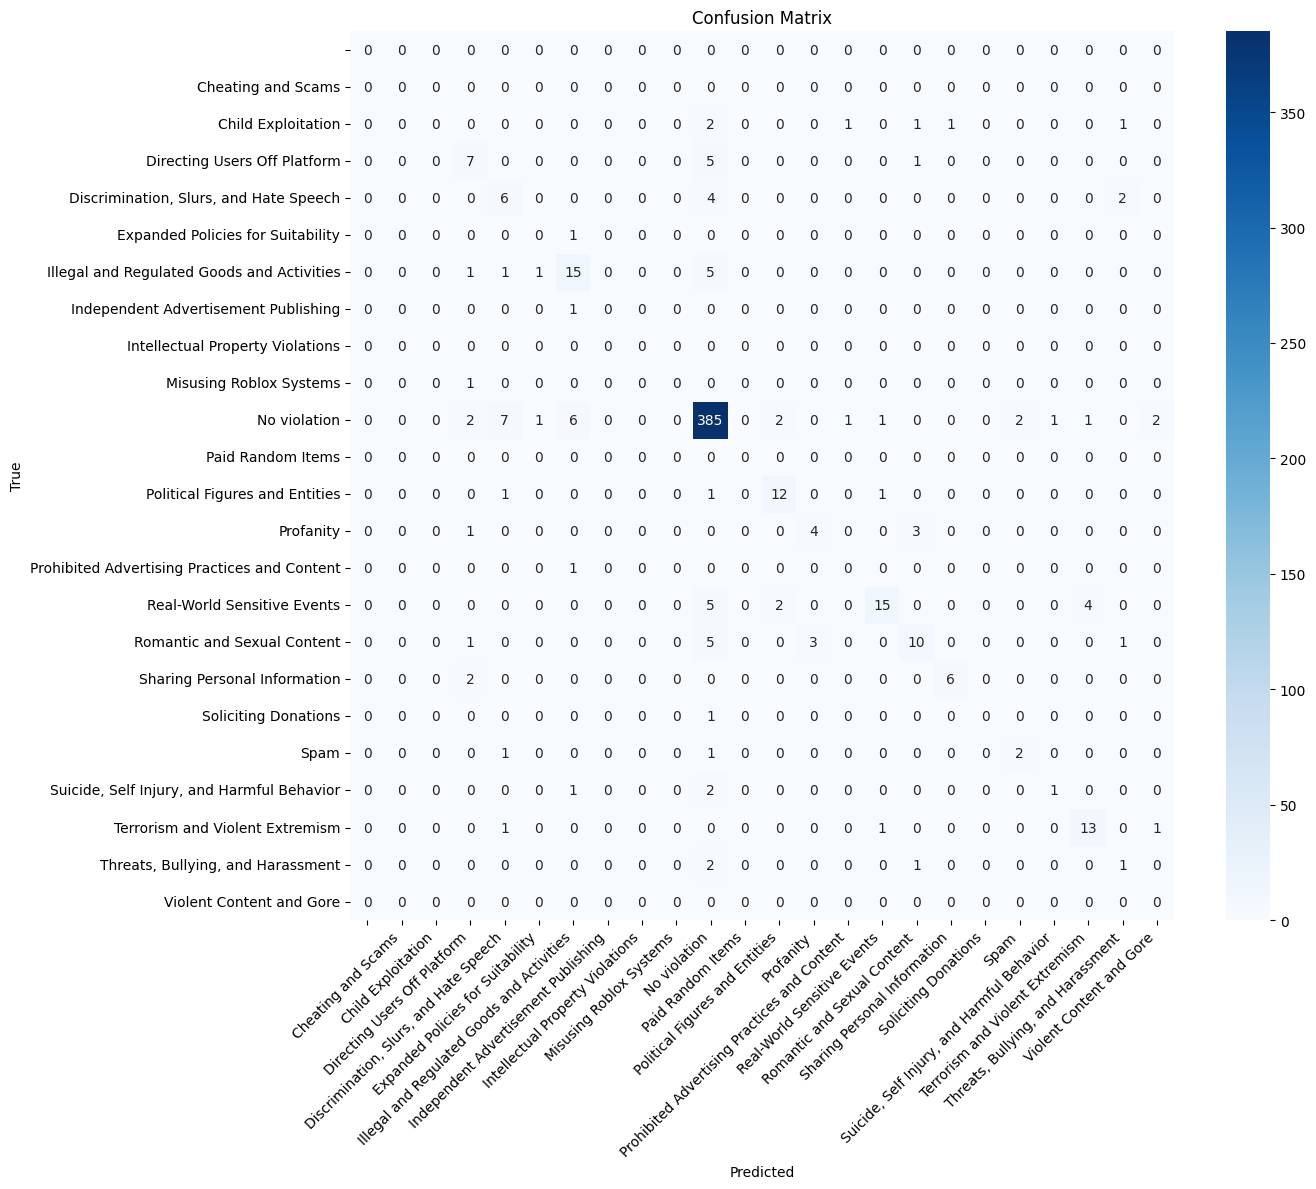

In [21]:
cm = confusion_matrix(true_names, pred_names, labels=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("lora-classification/confusion_matrix.png", dpi=150)
plt.show()